In [46]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

In [ ]:
df = pd.read_csv("../dataset/smart_grid_dataset.csv")
df.head()

In [ ]:
df = df.copy()


df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df = df.sort_values("Timestamp").reset_index(drop=True)

critical_cols = [
    "Voltage (V)",
    "Current (A)",
    "Power Consumption (kW)",
    "Reactive Power (kVAR)",
    "Power Factor",
    "Voltage Fluctuation (%)",
    "Temperature (°C)"
]

df = df.dropna(subset=critical_cols)

In [28]:
df.shape

(50000, 16)

In [29]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "Voltage (V)",
    "Current (A)",
    "Power Consumption (kW)",
    "Reactive Power (kVAR)",
    "Power Factor",
    "Voltage Fluctuation (%)",
    "Temperature (°C)"
]

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])


In [ ]:
import numpy as np

WINDOW_SIZE = 30

def create_windows(data, window_size):
    X = []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i])
    return np.array(X)

X_dl = create_windows(df[feature_cols].values, WINDOW_SIZE)

print(X_dl.shape)



(49970, 30, 7)


In [52]:
def create_windows_with_target(data, target_col_idx, window_size):
    X, y = [], []
    for i in range(window_size, len(data) - 1):
        X.append(data[i - window_size:i])
        y.append(data[i, target_col_idx])  # predict next step
    return np.array(X), np.array(y)
target_col = feature_cols.index("Power Consumption (kW)")

X_train, y_train = create_windows_with_target(
    df[feature_cols].values,
    target_col,
    WINDOW_SIZE
)

print(X_train.shape, y_train.shape)


(49969, 30, 7) (49969,)


In [47]:
class StressExtractor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.gru = nn.GRU(input_size, 32, batch_first=True)
        self.fc_pred = nn.Linear(32, 1)   # prediction head
        self.fc_stress = nn.Linear(32, 3) # stress head

    def forward(self, x):
        _, h = self.gru(x)
        h = h[-1]
        pred = self.fc_pred(h)
        stress = torch.sigmoid(self.fc_stress(h))
        return pred.squeeze(), stress


In [48]:
model = StressExtractor(input_size=7)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.float32)


In [50]:
EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    optimizer.zero_grad()

    pred, _ = model(X_tensor)
    loss = criterion(pred, y_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 2 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


Epoch 0 | Loss: 1.0060
Epoch 2 | Loss: 1.0028
Epoch 4 | Loss: 1.0013
Epoch 6 | Loss: 1.0009
Epoch 8 | Loss: 1.0008
Epoch 10 | Loss: 1.0006
Epoch 12 | Loss: 1.0002
Epoch 14 | Loss: 1.0000


In [67]:
model.eval()

with torch.no_grad():
    _, stress_outputs = model(torch.tensor(X_dl, dtype=torch.float32))

stress_outputs = stress_outputs.numpy()


In [70]:
def synthesize_state(stress_vec):
    trend, volatility, stability = stress_vec

    if trend > 0.7 and volatility > 0.6:
        return "ESCALATING"
    if stability < 0.4:
        return "UNSTABLE"
    return "STABLE"


In [71]:
system_states = [synthesize_state(s) for s in stress_outputs]


In [72]:
def decide(system_state, stress_vec):
    trend, volatility, stability = stress_vec

    if system_state == "ESCALATING":
        return {
            "action": "PREPARE",
            "priority": "P1",
            "confidence": round(float((trend + volatility) / 2), 2),
            "regret": {"act_now": "low", "wait": "high"}
        }

    if system_state == "UNSTABLE":
        return {
            "action": "INTERVENE",
            "priority": "P1",
            "confidence": round(float(1 - stability), 2),
            "regret": {"act_now": "medium", "wait": "high"}
        }

    return {
        "action": "MONITOR",
        "priority": "P3",
        "confidence": 0.5,
        "regret": {"act_now": "low", "wait": "low"}
    }


In [ ]:

stress_vec = stress_outputs[-1]
trend, volatility, stability = stress_vec


system_state = synthesize_state(stress_vec)

# Latest decision
decision = decide(system_state, stress_vec)


In [74]:
llm_context = {
    "system_state": system_state,
    "stress_summary": {
        "trend_level": "high" if trend > 0.7 else "medium" if trend > 0.4 else "low",
        "volatility_level": "high" if volatility > 0.6 else "medium",
        "stability_level": "low" if stability < 0.4 else "normal"
    },
    "decision": decision
}


In [75]:
explanation = (
    f"System state is {system_state}. "
    f"Stress trend is increasing with elevated volatility, "
    f"leading to a {decision['action']} recommendation."
)


In [76]:
final_log = {
    "timestamp": df["Timestamp"].iloc[-1],
    "system_state": system_state,
    "stress": stress_vec.tolist(),
    "decision": decision,
    "explanation": explanation
}


In [77]:
print(final_log)


{'timestamp': Timestamp('2025-06-04 19:45:00'), 'system_state': 'STABLE', 'stress': [0.45982199907302856, 0.49171265959739685, 0.5228456258773804], 'decision': {'action': 'MONITOR', 'priority': 'P3', 'confidence': 0.5, 'regret': {'act_now': 'low', 'wait': 'low'}}, 'explanation': 'System state is STABLE. Stress trend is increasing with elevated volatility, leading to a MONITOR recommendation.'}


In [78]:
print(stress_outputs[-5:])
print(system_state, decision)


[[0.4207391  0.45715073 0.5306551 ]
 [0.4526938  0.46297693 0.5363842 ]
 [0.47067654 0.4765542  0.548804  ]
 [0.4634983  0.48234054 0.53246605]
 [0.459822   0.49171266 0.5228456 ]]
STABLE {'action': 'MONITOR', 'priority': 'P3', 'confidence': 0.5, 'regret': {'act_now': 'low', 'wait': 'low'}}


In [63]:
np.std(stress_outputs, axis=0)


array([0.02327006, 0.02383632, 0.01881676], dtype=float32)

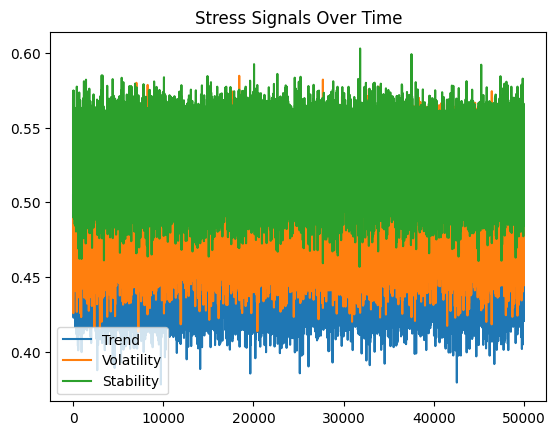

In [64]:
import matplotlib.pyplot as plt

plt.plot(stress_outputs[:, 0], label="Trend")
plt.plot(stress_outputs[:, 1], label="Volatility")
plt.plot(stress_outputs[:, 2], label="Stability")
plt.legend()
plt.title("Stress Signals Over Time")
plt.show()


In [65]:
load_series = df["Power Consumption (kW)"].values[WINDOW_SIZE:]
stress_trend = stress_outputs[:, 0]

corr = np.corrcoef(load_series, stress_trend)[0, 1]
print("Correlation:", corr)


Correlation: 0.005585441712455656
